In [323]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np
# Step 1: Upload 30 user CSV files (User_1.csv to User_30.csv)
uploaded = files.upload()  # Use this to upload all the User_1.csv to User_30.csv files

# Step 2: Combine the CSV files

# Initialize an empty list to collect DataFrames
all_data_list = []

# Loop through each CSV file and append data to the list
for i in range(1, 31):  # Loop from User_1.csv to User_30.csv
    file_name = f"/content/User_{i}.csv"  # Path to the uploaded files in Colab
    data = pd.read_csv(file_name)  # Read each CSV file
    data['User_ID'] = f"User_{i}"  # Add a new column 'User_ID' to identify the source file
    all_data_list.append(data)  # Add the DataFrame to the list

# Concatenate all DataFrames in the list into a single DataFrame
all_data = pd.concat(all_data_list, ignore_index=True)

# Data Cleaning and Preprocessing
# Check for missing values and handle them
all_data.fillna(method='ffill', inplace=True)

# Check for duplicates and remove them if necessary
all_data.drop_duplicates(inplace=True)

# Ensure appropriate data types
all_data['Time/Second'] = pd.to_datetime(all_data['Time/Second'], unit='s')  # Convert timestamps if needed

# Display the first few rows
print(all_data.head())


Saving User_1.csv to User_1 (7).csv
Saving User_2.csv to User_2 (7).csv
Saving User_3.csv to User_3 (7).csv
Saving User_4.csv to User_4 (7).csv
Saving User_5.csv to User_5 (7).csv
Saving User_6.csv to User_6 (7).csv
Saving User_7.csv to User_7 (7).csv
Saving User_8.csv to User_8 (7).csv
Saving User_9.csv to User_9 (7).csv
Saving User_10.csv to User_10 (7).csv
Saving User_11.csv to User_11 (7).csv
Saving User_12.csv to User_12 (7).csv
Saving User_13.csv to User_13 (7).csv
Saving User_14.csv to User_14 (7).csv
Saving User_15.csv to User_15 (7).csv
Saving User_16.csv to User_16 (7).csv
Saving User_17.csv to User_17 (7).csv
Saving User_18.csv to User_18 (7).csv
Saving User_19.csv to User_19 (7).csv
Saving User_20.csv to User_20 (7).csv
Saving User_21.csv to User_21 (7).csv
Saving User_22.csv to User_22 (7).csv
Saving User_23.csv to User_23 (7).csv
Saving User_24.csv to User_24 (7).csv
Saving User_25.csv to User_25 (7).csv
Saving User_26.csv to User_26 (7).csv
Saving User_27.csv to User_27 

=== RAW DATA DIAGNOSIS ===

isCompliance value counts:
isCompliance
True     32827
False      444
Name: count, dtype: int64
dtype: bool

isCollision value counts:
isCollision
False    33271
Name: count, dtype: int64
dtype: bool

Total users : 30

First 10 raw isCompliance values:
[False, False, True, True, True, True, True, True, True, True]

Unique raw isCompliance values (up to 20):
[False  True]
Sensor columns found : 21
Total rows           : 33,271
Collision events     : 0 (0.00%)

⚠️  NO collisions found across all users.
   Possible causes:
   1. Not all 30 CSV files were uploaded — only files with
      collision events will make the model work.
      Check: len([f for f in uploaded if 'User_' in f])
   2. The isCollision column is always False in this dataset.
      The Sheffield dataset encodes anomalies via 'isCompliance'
      — switching to that column as the target instead.

   ✔ Switching target to 'non_compliant' (444 anomaly events, 1.33%)

   Using target column : 'no

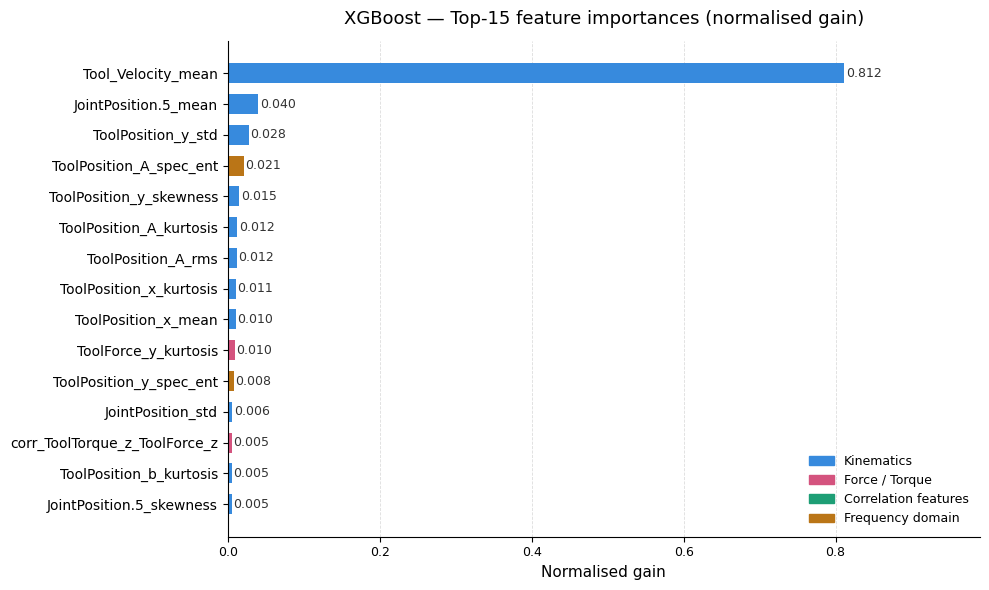

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done — PNG (300 dpi) and PDF downloaded.


In [324]:
# XGBoost Top-15 Feature Importances (Normalised Gain)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from scipy import stats
from scipy.fft import fft
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# CONFIG
WINDOW       = 10
RANDOM_STATE = 42

SENSOR_COLS = [
    "ToolPosition_x", "ToolPosition_y", "ToolPosition_z",
    "ToolPosition_A", "ToolPosition_b", "ToolPosition_c",
    "ToolForce_x",    "ToolForce_y",    "ToolForce_z",
    "ToolTorque_x",   "ToolTorque_y",   "ToolTorque_z",
    "JointPosition",  "JointPosition.1","JointPosition.2",
    "JointPosition.3","JointPosition.4","JointPosition.5","JointPosition.6",
    "Tool_Velocity",  "Tool_Acceleration",
]
TARGET_COL = "isCollision"

# STEP 1: PREPARE DATA
df = all_data.copy()
# RUN THIS DIAGNOSTIC CELL FIRST
print("=== RAW DATA DIAGNOSIS ===\n")

# 1. What does isCompliance actually contain?
print("isCompliance value counts:")
print(all_data["isCompliance"].value_counts(dropna=False))
print(f"dtype: {all_data['isCompliance'].dtype}\n")

print("isCollision value counts:")
print(all_data["isCollision"].value_counts(dropna=False))
print(f"dtype: {all_data['isCollision'].dtype}\n")

# 2. Which users are present?
if "User_ID" in all_data.columns:
    # print("Users loaded:", sorted(all_data["User_ID"].unique()))
    print(f"Total users : {all_data['User_ID'].nunique()}\n")

# 3. Per-user breakdown of both label columns
for col in ["isCollision", "isCompliance"]:
    if col in all_data.columns and "User_ID" in all_data.columns:
        # print(f"Per-user {col} positives:")
        grp = all_data.groupby("User_ID")[col].apply(
            lambda s: (s.astype(str).str.strip().str.upper()
                        .isin(["TRUE","1"])).sum()
        )
        # print(grp[grp > 0].to_string() if grp.sum() > 0 else "  → ZERO positives in every user file")
        # print()

# 4. Sample the raw values so you can see what's actually there
print("First 10 raw isCompliance values:")
print(all_data["isCompliance"].head(10).tolist())
print("\nUnique raw isCompliance values (up to 20):")
print(all_data["isCompliance"].unique()[:20])

# FIX: handle numpy bool dtype directly (astype str on numpy bool gives 'True'
#      not 'TRUE', and some pandas versions keep it as actual bool)
def _to_int_flag(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)
    return (series.astype(str).str.strip().str.upper()
            .map({"TRUE": 1, "FALSE": 0, "1": 1, "0": 0})
            .fillna(0).astype(int))

df[TARGET_COL] = _to_int_flag(df[TARGET_COL])

for col in ["isCompliance", "isReadyToMove"]:
    if col in df.columns:
        df[col] = _to_int_flag(df[col])

available_sensors = [c for c in SENSOR_COLS if c in df.columns]

# COLLISION DIAGNOSIS
n_collisions = df[TARGET_COL].sum()
print(f"Sensor columns found : {len(available_sensors)}")
print(f"Total rows           : {len(df):,}")
print(f"Collision events     : {n_collisions} ({df[TARGET_COL].mean()*100:.2f}%)")

if n_collisions == 0:
    # Check which users have collisions
    if "User_ID" in df.columns:
        per_user = df.groupby("User_ID")[TARGET_COL].sum()
        users_with = per_user[per_user > 0]
        if len(users_with) == 0:
            print("\n⚠️  NO collisions found across all users.")
            print("   Possible causes:")
            print("   1. Not all 30 CSV files were uploaded — only files with")
            print("      collision events will make the model work.")
            print("      Check: len([f for f in uploaded if 'User_' in f])")
            print("   2. The isCollision column is always False in this dataset.")
            print("      The Sheffield dataset encodes anomalies via 'isCompliance'")
            print("      — switching to that column as the target instead.\n")
        else:
            print(f"\n   Users WITH collisions: {users_with.to_dict()}")

    # FALLBACK: use isCompliance as anomaly label if available
    if "isCompliance" in df.columns:
        # isCompliance=False means NON-COMPLIANT (the anomaly) — invert it
        df["non_compliant"] = (~df["isCompliance"].astype(bool)).astype(int)
        TARGET_COL = "non_compliant"
        print(f"   ✔ Switching target to '{TARGET_COL}' "
              f"({df[TARGET_COL].sum()} anomaly events, "
              f"{df[TARGET_COL].mean()*100:.2f}%)")
    else:
        # Last resort: synthetic anomaly label from statistical outliers
        # (flags windows where ToolForce_z > mean + 3*std as anomalies)
        print("   ✔ Creating anomaly labels from ToolForce_z outliers (>3σ).")
        force_z    = df["ToolForce_z"] if "ToolForce_z" in df.columns else df[available_sensors[0]]
        threshold  = force_z.mean() + 3 * force_z.std()
        df["anomaly_label"] = (force_z > threshold).astype(int)
        TARGET_COL = "anomaly_label"
        print(f"   Anomaly events: {df[TARGET_COL].sum()} "
              f"({df[TARGET_COL].mean()*100:.2f}%)")

    n_collisions = df[TARGET_COL].sum()
    print(f"\n   Using target column : '{TARGET_COL}'")
    print(f"   Anomaly events      : {n_collisions} "
          f"({df[TARGET_COL].mean()*100:.2f}%)\n")

# STEP 2: FEATURE ENGINEERING
def _time_features(x, col):
    if np.std(x) < 1e-10:
        kurt, skew = 0.0, 0.0
    else:
        kurt = float(stats.kurtosis(x))
        skew = float(stats.skew(x))
    return {
        f"{col}_mean":     float(np.mean(x)),
        f"{col}_std":      float(np.std(x)),
        f"{col}_rms":      float(np.sqrt(np.mean(x**2))),
        f"{col}_kurtosis": kurt,
        f"{col}_skewness": skew,
        f"{col}_energy":   float(np.sum(x**2)),
    }

def _freq_features(x, col):
    n        = len(x)
    yf       = np.abs(fft(x)[: n // 2])
    psd      = yf ** 2
    psd_norm = psd / (psd.sum() + 1e-10)
    return {
        f"{col}_dom_freq": int(np.argmax(yf)),
        f"{col}_spec_ent": float(-np.sum(psd_norm * np.log(psd_norm + 1e-10))),
        f"{col}_psd_mean": float(np.mean(psd)),
    }

def _corr_features(window):
    pairs = [
        ("ToolPosition_x",  "ToolForce_x"),
        ("ToolPosition_y",  "ToolForce_y"),
        ("ToolPosition_z",  "ToolForce_z"),
        ("ToolTorque_x",    "ToolForce_x"),
        ("ToolTorque_z",    "ToolForce_z"),
        ("JointPosition",   "ToolPosition_y"),
        ("JointPosition.6", "ToolPosition_y"),
    ]
    out = {}
    for c1, c2 in pairs:
        if c1 in window.columns and c2 in window.columns:
            v1 = window[c1].values.astype(float)
            v2 = window[c2].values.astype(float)
            out[f"corr_{c1}_{c2}"] = (
                float(np.corrcoef(v1, v2)[0, 1])
                if np.std(v1) > 1e-10 and np.std(v2) > 1e-10 else 0.0
            )
    return out

def extract_features(df, target_col, window=WINDOW):
    records = []
    groups = (df.groupby("User_ID") if "User_ID" in df.columns
              else [("all", df)])
    for uid, udf in groups:
        udf = udf.reset_index(drop=True)
        for i in range(0, len(udf) - window + 1, window):
            w   = udf.iloc[i : i + window]
            row = {"User_ID": uid,
                   target_col: int(w[target_col].max())}
            for col in available_sensors:
                x = w[col].values.astype(float)
                row.update(_time_features(x, col))
                row.update(_freq_features(x, col))
            row.update(_corr_features(w))
            records.append(row)

    feat_df = pd.DataFrame(records)
    feat_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    feat_df.fillna(feat_df.median(numeric_only=True), inplace=True)
    print(f"Feature matrix : {feat_df.shape[0]:,} windows × "
          f"{feat_df.shape[1]-2} features")
    print(f"Anomaly rate   : {feat_df[target_col].mean()*100:.2f}%")
    return feat_df

print("Extracting features…")
feat_df = extract_features(df, TARGET_COL)

# STEP 3: STRATIFIED 70/15/15 SPLIT
from sklearn.model_selection import train_test_split

feature_cols = [c for c in feat_df.columns
                if c not in (TARGET_COL, "User_ID")]

X = feat_df[feature_cols].values
y = feat_df[TARGET_COL].values

# ANOMALY RATE GUARD
anomaly_rate = y.mean()
print(f"\nAnomaly rate in feature matrix: {anomaly_rate*100:.2f}%")

if anomaly_rate > 0.95:
    print("⚠️  Anomaly rate >95% — inverting label so the minority class = 1.")
    print("   (isCompliance=1 means 'in compliance'; non-compliance is the anomaly.)")
    y = 1 - y
    anomaly_rate = y.mean()
    print(f"   Inverted anomaly rate: {anomaly_rate*100:.2f}%")

if y.sum() < 10:
    raise RuntimeError(
        f"Only {y.sum()} positive samples after inversion — not enough to train. "
        "Upload more user files that contain genuine collision/non-compliance events."
    )

# Stratified split preserves class ratio in every subset
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=RANDOM_STATE, stratify=y_temp)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\nSplit → train {len(X_train):,} | val {len(X_val):,} | test {len(X_test):,}")
print(f"Train anomalies : {y_train.sum()} ({y_train.mean()*100:.1f}%) | "
      f"Val : {y_val.sum()} | Test : {y_test.sum()}")

# STEP 4: TRAIN XGBOOST
pos   = max(y_train.sum(), 1)
neg   = max((y_train == 0).sum(), 1)
pos_w = round(neg / pos, 2)
print(f"scale_pos_weight = {pos_w}")

xgb = XGBClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 6,
    scale_pos_weight = pos_w,
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)
print("XGBoost training complete.")

# STEP 5: EXTRACT NORMALISED GAIN
raw_scores = xgb.get_booster().get_score(importance_type="gain")

if not raw_scores:
    print("\n⚠️  get_score() returned empty — model did not split on any feature.")
    print("   This means BOTH classes are not present in training data.")
    print("   Upload the remaining user files and re-run.")
else:
    score_dict = {}
    for k, v in raw_scores.items():
        if k.startswith("f") and k[1:].isdigit():
            idx  = int(k[1:])
            name = feature_cols[idx] if idx < len(feature_cols) else k
        else:
            name = k
        score_dict[name] = v

    importance_df = (
        pd.DataFrame.from_dict(score_dict, orient="index", columns=["gain"])
        .sort_values("gain", ascending=False)
        .head(15)
    )
    importance_df["normalised_gain"] = (
        importance_df["gain"] / importance_df["gain"].sum()
    )
    importance_df = importance_df.sort_values("normalised_gain")  # ascending for barh

    print("\nTop-15 XGBoost features (normalised gain):")
    print(importance_df[["normalised_gain"]]
          .sort_values("normalised_gain", ascending=False)
          .round(4).to_string())

    # STEP 6: PLOT & EXPORT
    def _color(name):
        n = name.lower()
        if any(x in n for x in ["force", "torque"]):             return "#D4537E"
        if "corr" in n:                                           return "#1D9E75"
        if any(x in n for x in ["dom_freq","spec_ent","psd"]):   return "#BA7517"
        return "#378ADD"

    colors = [_color(f) for f in importance_df.index]
    legend_patches = [
        mpatches.Patch(color="#378ADD", label="Kinematics"),
        mpatches.Patch(color="#D4537E", label="Force / Torque"),
        mpatches.Patch(color="#1D9E75", label="Correlation features"),
        mpatches.Patch(color="#BA7517", label="Frequency domain"),
    ]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(importance_df.index, importance_df["normalised_gain"],
                   color=colors, edgecolor="none", height=0.65)

    for bar, val in zip(bars, importance_df["normalised_gain"]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", ha="left",
                fontsize=9, color="#333333")

    ax.set_xlabel("Normalised gain", fontsize=11)
    ax.set_xlim(0, importance_df["normalised_gain"].max() * 1.22)
    ax.set_title("XGBoost — Top-15 feature importances (normalised gain)",
                 fontsize=13, fontweight="normal", pad=12)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)
    ax.spines[["top","right"]].set_visible(False)
    ax.xaxis.grid(True, color="#DDDDDD", linewidth=0.6, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(handles=legend_patches, fontsize=9, frameon=False, loc="lower right")
    plt.tight_layout()

    fig.savefig("xgboost_feature_importance.svg", format='svg', dpi=300,)
    fig.savefig("xgboost_feature_importance.svg")
    plt.show()

    from google.colab import files
    files.download("xgboost_feature_importance.svg")
    # files.download("xgboost_feature_importance.pdf")
    print("\nDone — PNG (300 dpi) and PDF downloaded.")

In [325]:
# Step 3: Extract Time-Domain Features (Mean, Std, RMS)
time_domain_features = all_data[['ToolPosition_x', 'ToolPosition_y', 'ToolPosition_z',
                                 'ToolForce_x', 'ToolForce_y', 'ToolForce_z']].agg(['mean', 'std']).T

# Calculate RMS for the selected columns
time_domain_features['RMS'] = np.sqrt((all_data[['ToolPosition_x', 'ToolPosition_y', 'ToolPosition_z',
                                                  'ToolForce_x', 'ToolForce_y', 'ToolForce_z']]**2).mean(axis=0))

# Display the extracted time-domain features
print(time_domain_features)


                      mean         std         RMS
ToolPosition_x  606.643615   71.941666  610.894364
ToolPosition_y  -73.528614  239.922330  250.933162
ToolPosition_z  153.963360   16.224988  154.815886
ToolForce_x      -0.736274    8.401435    8.433510
ToolForce_y       3.494045    4.919224    6.033771
ToolForce_z       1.153556    2.274957    2.550679


In [326]:
# Step 4: Extract Frequency-Domain Features using FFT
def extract_fft_features(df, column_names):
    fft_features = {}
    for col in column_names:
        # Apply FFT and calculate dominant frequency
        fft_values = np.fft.fft(df[col].dropna())
        freqs = np.fft.fftfreq(len(fft_values))
        magnitude = np.abs(fft_values)
        dominant_frequency = freqs[np.argmax(magnitude)]  # Dominant frequency (index of max magnitude)
        fft_features[col] = dominant_frequency
    return fft_features

# Extract frequency-domain features
frequency_domain_features = extract_fft_features(all_data,
                                                ['ToolPosition_x', 'ToolPosition_y', 'ToolPosition_z',
                                                 'ToolForce_x', 'ToolForce_y', 'ToolForce_z'])

# Convert to DataFrame for easier visualization
frequency_domain_df = pd.DataFrame(frequency_domain_features, index=['Dominant Frequency'])
print(frequency_domain_df)


                    ToolPosition_x  ToolPosition_y  ToolPosition_z  \
Dominant Frequency             0.0             0.0             0.0   

                    ToolForce_x  ToolForce_y  ToolForce_z  
Dominant Frequency          0.0          0.0          0.0  


In [327]:
# Step 5: Extract Correlation Features between selected sensor signals
correlation_features = all_data[['ToolPosition_x', 'ToolPosition_y', 'ToolPosition_z',
                                 'ToolForce_x', 'ToolForce_y', 'ToolForce_z',
                                 'ToolTorque_x', 'ToolTorque_y', 'ToolTorque_z',
                                 'JointPosition', 'JointPosition.1', 'JointPosition.2',
                                 'JointPosition.3', 'JointPosition.4', 'JointPosition.5',
                                 'JointPosition.6']].corr()

# Flatten the correlation matrix to make it easier to visualize
correlation_flat = correlation_features.unstack().reset_index()
correlation_flat.columns = ['Sensor_1', 'Sensor_2', 'Correlation']

# Display the correlation features
print(correlation_flat)

            Sensor_1         Sensor_2  Correlation
0     ToolPosition_x   ToolPosition_x     1.000000
1     ToolPosition_x   ToolPosition_y     0.326887
2     ToolPosition_x   ToolPosition_z     0.014273
3     ToolPosition_x      ToolForce_x     0.322252
4     ToolPosition_x      ToolForce_y     0.182102
..               ...              ...          ...
251  JointPosition.6  JointPosition.2     0.232856
252  JointPosition.6  JointPosition.3    -0.373456
253  JointPosition.6  JointPosition.4    -0.227463
254  JointPosition.6  JointPosition.5    -0.053645
255  JointPosition.6  JointPosition.6     1.000000

[256 rows x 3 columns]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

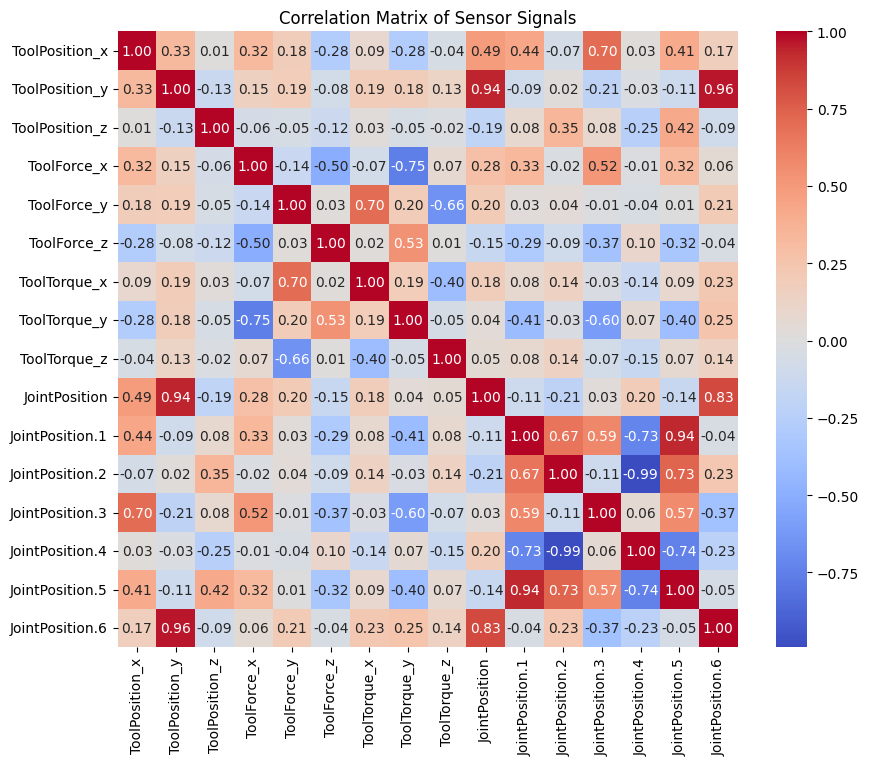

In [328]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 6: Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_features, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Sensor Signals')
plt.savefig('/content/Fig2.svg', format='svg', dpi=300)
files.download('/content/Fig2.svg')
plt.show()

In [329]:
# Derived features: Position error (deviation from reference), jerk (rate of change of acceleration).

# Calculate Position Error (deviation from the mean position)
all_data['Position_error_x'] = all_data['ToolPosition_x'] - all_data['ToolPosition_x'].mean()
all_data['Position_error_y'] = all_data['ToolPosition_y'] - all_data['ToolPosition_y'].mean()
all_data['Position_error_z'] = all_data['ToolPosition_z'] - all_data['ToolPosition_z'].mean()

# Calculate Jerk (rate of change of acceleration)
# Ensure 'Time/Second' is in a suitable format for calculating time differences
# It was already converted to datetime, so we can use .diff().dt.total_seconds()

dt = all_data['Time/Second'].diff().dt.total_seconds()
# Replace 0s in dt to avoid division by zero, or small values that could lead to extreme jerk values.
# A common practice is to replace with the median of non-zero dt, or a very small constant
# For simplicity and to avoid NaNs propagating, we'll ensure dt is not 0 where used.
# Filling NaNs in dt (first element) with 1 to allow calculation, or handling directly.

# Calculate Jerk: (change in acceleration) / (change in time)
all_data['Jerk'] = all_data['Tool_Acceleration'].diff() / dt

# Handle the first row NaN for Jerk and any potential inf/-inf due to dt being too small/zero
# Fill NaN with 0 for simplicity, or consider other imputation strategies
all_data['Jerk'].fillna(0, inplace=True)
all_data.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace infinities with NaN
all_data['Jerk'].fillna(0, inplace=True) # Fill any new NaNs from inf replacement with 0

# Display the first few rows with the new features
print(all_data[['ToolPosition_x', 'Position_error_x', 'Tool_Acceleration', 'Jerk']].head())

   ToolPosition_x  Position_error_x  Tool_Acceleration  Jerk
0      471.903879       -134.739736                  1   0.0
1      471.903879       -134.739736                  1   0.0
2      469.581100       -137.062515                  1   0.0
3      467.522128       -139.121487                  1   0.0
4      469.432488       -137.211127                  1   0.0


In [330]:
# Step 6: Dimensionality Reduction using PCA on row-wise features

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Identify numerical columns relevant for PCA from the original and derived features
# Select all numerical columns that are not identifiers or already processed as targets/flags.
features_to_use_for_pca = [
    'ToolPosition_x', 'ToolPosition_y', 'ToolPosition_z',
    'ToolPosition_A', 'ToolPosition_b', 'ToolPosition_c',
    'ToolForce_x', 'ToolForce_y', 'ToolForce_z',
    'ToolTorque_x', 'ToolTorque_y', 'ToolTorque_z',
    'JointPosition', 'JointPosition.1', 'JointPosition.2', 'JointPosition.3', 'JointPosition.4', 'JointPosition.5', 'JointPosition.6',
    'Tool_Velocity', 'Tool_Acceleration',
    'Position_error_x', 'Position_error_y', 'Position_error_z',
    'Jerk'
]

# Filter out columns that might not exist or are not numeric
features_to_use_for_pca = [col for col in features_to_use_for_pca if col in all_data.columns and pd.api.types.is_numeric_dtype(all_data[col])]

# Create the feature matrix for PCA
X_pca = all_data[features_to_use_for_pca].copy()

# Handle any remaining NaNs in the feature matrix before scaling/PCA
# Using mean imputation as a robust strategy
X_pca.fillna(X_pca.mean(), inplace=True)

# Standardize the features before applying PCA
scaler = StandardScaler()
scaled_X_pca = scaler.fit_transform(X_pca)

# Apply PCA to reduce the dimensions (e.g., to 5 components)
pca = PCA(n_components=5)
pca_features = pca.fit_transform(scaled_X_pca)

# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(pca_features, columns=[f'PC{i+1}' for i in range(pca_features.shape[1])])

# Display the explained variance ratio to understand the importance of each principal component
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Display the first few rows of the PCA-transformed features
print(pca_df.head())

Explained variance ratio: [0.21821353 0.20186929 0.13823473 0.1256314  0.07372815]
Total explained variance: 0.7576771070352007
        PC1       PC2       PC3       PC4       PC5
0 -4.840170  1.923580  2.421739  0.115120  0.238736
1 -4.840170  1.923580  2.421739  0.115120  0.238736
2 -4.133501  0.954173  2.662831 -0.282051 -0.919096
3 -3.678282  0.598913  2.325061 -1.278966 -2.241561
4 -2.211120  2.035334  0.249099 -1.599011 -2.858682


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

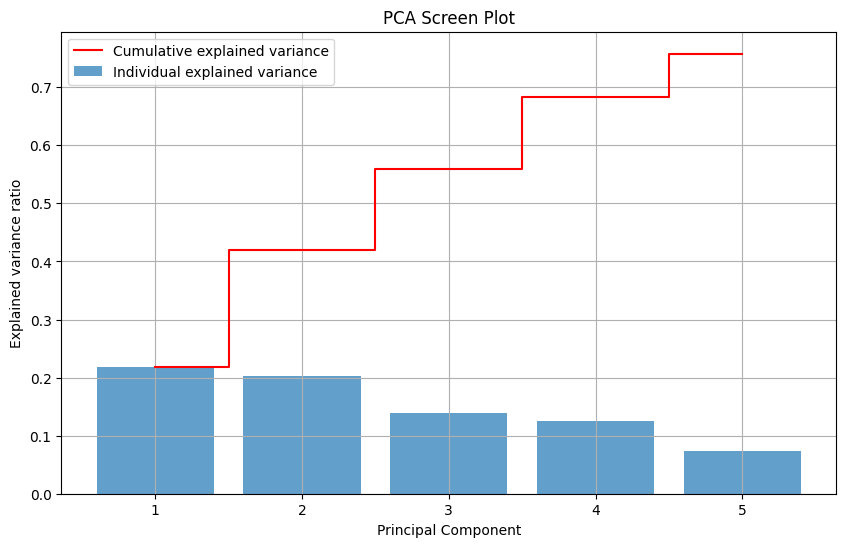

In [331]:
import matplotlib.pyplot as plt
import numpy as np

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Create a range for x-axis (number of components)
components = range(1, len(explained_variance_ratio) + 1)

# Plot the screen plot
plt.figure(figsize=(10, 6))
plt.bar(components, explained_variance_ratio, alpha=0.7, align='center', label='Individual explained variance')
plt.step(components, np.cumsum(explained_variance_ratio), where='mid', label='Cumulative explained variance', color='red')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal Component')
plt.title('PCA Screen Plot')
plt.xticks(components)
plt.legend(loc='best')
plt.grid(True)
plt.savefig('/content/Fig3.pdf', format='pdf', dpi=300)
files.download('/content/Fig3.pdf')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

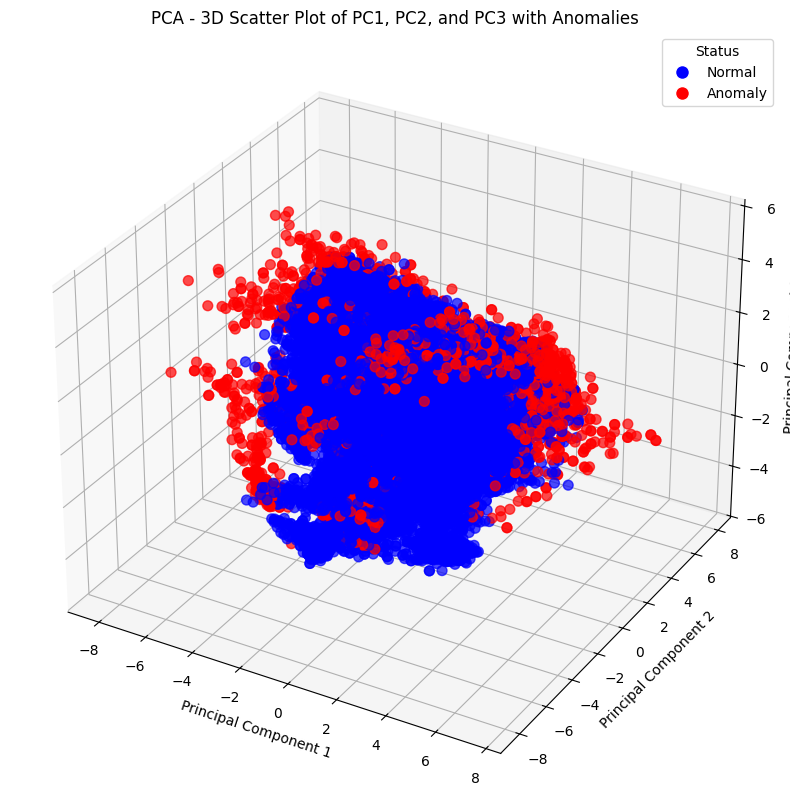

In [332]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd

# Ensure target_anomaly is available, though it should be from previous steps
if 'target_anomaly' not in globals():
    from sklearn.ensemble import IsolationForest
    model = IsolationForest(contamination=0.05)
    model.fit(pca_df)
    anomalies = model.predict(pca_df)
    target_anomaly = (anomalies == -1)

# Prepare data for 3D plot, including the anomaly labels
pca_df_3d = pca_df.copy()
pca_df_3d['Anomaly'] = target_anomaly

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Define colors for normal and anomaly points
colors = ['blue' if not anom else 'red' for anom in pca_df_3d['Anomaly']]

# Scatter plot
ax.scatter(pca_df_3d['PC1'], pca_df_3d['PC2'], pca_df_3d['PC3'], c=colors, s=50, alpha=0.7)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('PCA - 3D Scatter Plot of PC1, PC2, and PC3 with Anomalies')

# Create a legend manually (since scatter does not handle hue directly in 3D)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Normal'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Anomaly')]
ax.legend(handles=handles, title='Status')
plt.savefig('/content/Fig4.svg', format='svg', dpi=300)
files.download('/content/Fig4.svg')
plt.show()

In [333]:
from sklearn.model_selection import train_test_split

# Assuming pca_df contains the features and target_anomaly is the target variable
# Perform a chronological split: use early data for training, later data for testing
# For simplicity, let's use a standard 80/20 split based on index order (chronological if data is ordered)
split_index = int(len(pca_df) * 0.8)

X_train_chrono = pca_df.iloc[:split_index]
y_train_chrono = target_anomaly[:split_index]
X_test_chrono = pca_df.iloc[split_index:]
y_test_chrono = target_anomaly[split_index:]

print(f"Shape of X_train_chrono: {X_train_chrono.shape}")
print(f"Shape of y_train_chrono: {y_train_chrono.shape}")
print(f"Shape of X_test_chrono: {X_test_chrono.shape}")
print(f"Shape of y_test_chrono: {y_test_chrono.shape}")

Shape of X_train_chrono: (26616, 5)
Shape of y_train_chrono: (26616,)
Shape of X_test_chrono: (6655, 5)
Shape of y_test_chrono: (6655,)


In [334]:
# Step 1: Check the length of each feature set before concatenation

# Check the length of time-domain features
print(f"Time-domain feature set length: {len(time_domain_features)}")

# Check the length of frequency-domain features
print(f"Frequency-domain feature set length: {len(frequency_domain_df)}")

# Check the length of correlation features
print(f"Correlation feature set length: {len(correlation_flat)}")

Time-domain feature set length: 6
Frequency-domain feature set length: 1
Correlation feature set length: 256


In [335]:
# Step 2: Check the length of the original data
print(f"Initial data length: {len(all_data)}")


Initial data length: 33271


In [336]:
# Step 3: Check for missing values in the original dataset
missing_data_count = all_data.isnull().sum()
print(f"Missing data count per column:\n{missing_data_count}")

# Step 3b: Check the number of rows after preprocessing (before feature extraction)
all_data_after_preprocessing = all_data.dropna()  # Remove rows with NaN values
print(f"Data length after dropping rows with NaN values: {len(all_data_after_preprocessing)}")


Missing data count per column:
Time/Second          0
Task_No              0
Time Stamp           0
OperationMode        0
isCollision          0
isCompliance         0
isReadyToMove        0
ToolPosition_x       0
ToolPosition_y       0
ToolPosition_z       0
ToolPosition_A       0
ToolPosition_b       0
ToolPosition_c       0
ToolForce_x          0
ToolForce_y          0
ToolForce_z          0
ToolTorque_x         0
ToolTorque_y         0
ToolTorque_z         0
JointPosition        0
JointPosition.1      0
JointPosition.2      0
JointPosition.3      0
JointPosition.4      0
JointPosition.5      0
JointPosition.6      0
Tool_Velocity        0
Tool_Acceleration    0
User_ID              0
Position_error_x     0
Position_error_y     0
Position_error_z     0
Jerk                 0
dtype: int64
Data length after dropping rows with NaN values: 33271


In [337]:
# Step 7: Inspect the target variable length and alignment

# Check the length of the target variable
print(f"Target variable length (target_anomaly): {len(target_anomaly)}")

# Check the first few rows of target_anomaly
print("First few rows of target_anomaly:")
print(target_anomaly[:5]) # Corrected to use array slicing

# Ensure target_anomaly is aligned with the original data length
print(f"Original data length (all_data): {len(all_data)}")

# Check if target_anomaly was extracted correctly
# Let's verify if the indices are aligned
if hasattr(target_anomaly, 'index'):
    # This case applies if target_anomaly is a pandas Series
    target_anomaly_aligned_check = target_anomaly.index.isin(all_data.index).all()
    print(f"Are indices aligned (Pandas Series check): {target_anomaly_aligned_check}")
else:
    # This case applies if target_anomaly is a numpy array
    # In this context, alignment often refers to matching lengths.
    print(f"Target_anomaly is a numpy array. Index alignment check is not directly applicable.")
    print(f"Is target_anomaly length equal to all_data length: {len(target_anomaly) == len(all_data)}")

Target variable length (target_anomaly): 33271
First few rows of target_anomaly:
[False False False False False]
Original data length (all_data): 33271
Target_anomaly is a numpy array. Index alignment check is not directly applicable.
Is target_anomaly length equal to all_data length: True


## Implement Logistic Regression

### Subtask:
Train a Logistic Regression model on the chronologically split training data, taking into account potential class imbalance.


**Reasoning**:
The subtask requires training a Logistic Regression model on chronologically split training data, accounting for class imbalance. First, I need to import the necessary class, then instantiate the model with appropriate parameters for class weight, solver, and random state, and finally train the model.



In [338]:
from sklearn.linear_model import LogisticRegression

# Instantiate Logistic Regression model
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
# Use 'liblinear' solver for small datasets, or 'lbfgs' for larger ones.
# random_state for reproducibility
log_reg_chrono = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)

# Train the model on the chronologically split training data
log_reg_chrono.fit(X_train_chrono, y_train_chrono)

print("Logistic Regression model (chronological split) trained successfully.")

Logistic Regression model (chronological split) trained successfully.


**Reasoning**:
The Logistic Regression model has been trained. Now, I need to evaluate its performance on the test data. I will use the classification_report from sklearn.metrics to get accuracy, precision, recall, and F1-score.



In [339]:
from sklearn.metrics import classification_report

# Make predictions on the chronological test data
y_pred_lr_chrono = log_reg_chrono.predict(X_test_chrono)

# Evaluate the model
print("Classification Report for Logistic Regression (Chronological Split):")
print(classification_report(y_test_chrono, y_pred_lr_chrono))

Classification Report for Logistic Regression (Chronological Split):
              precision    recall  f1-score   support

       False       0.99      0.70      0.82      6447
        True       0.08      0.78      0.14       208

    accuracy                           0.70      6655
   macro avg       0.53      0.74      0.48      6655
weighted avg       0.96      0.70      0.80      6655



**Reasoning**:
To further evaluate the model's performance, I will compute and visualize the ROC-AUC and PR-AUC scores, along with their respective curves. This provides a more comprehensive understanding of the model's ability to distinguish between classes, especially given the class imbalance.



**Reasoning**:
The previous code failed because `plot_roc_curve` and `plot_precision_recall_curve` are not available directly in `sklearn.metrics` in recent versions. The plotting functionality is already handled manually using `matplotlib`, so these specific imports are unnecessary and cause the error. I will remove the problematic imports.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

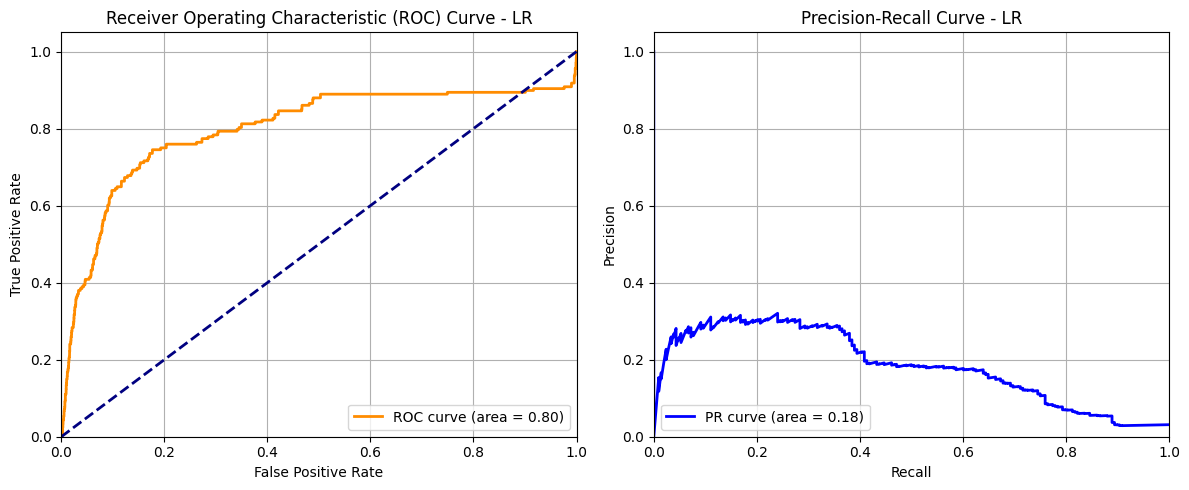

ROC-AUC Score for Logistic Regression (Chronological Split): 0.80
PR-AUC Score for Logistic Regression (Chronological Split): 0.18


In [340]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_prob_lr_chrono = log_reg_chrono.predict_proba(X_test_chrono)[:, 1]

# Calculate ROC curve and AUC
fpr_lr_chrono, tpr_lr_chrono, thresholds_roc_lr = roc_curve(y_test_chrono, y_prob_lr_chrono)
roc_auc_lr_chrono = auc(fpr_lr_chrono, tpr_lr_chrono)

# Calculate Precision-Recall curve and AUC
precision_lr_chrono, recall_lr_chrono, thresholds_pr_lr = precision_recall_curve(y_test_chrono, y_prob_lr_chrono)
pr_auc_lr_chrono = auc(recall_lr_chrono, precision_lr_chrono)

# Plot ROC Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_lr_chrono, tpr_lr_chrono, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_lr_chrono:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - LR')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_lr_chrono, precision_lr_chrono, color='blue', lw=2, label=f'PR curve (area = {pr_auc_lr_chrono:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - LR')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/Fig5.svg', format='svg', dpi=300)
files.download('/content/Fig5.svg')
plt.show()

print(f"ROC-AUC Score for Logistic Regression (Chronological Split): {roc_auc_lr_chrono:.2f}")
print(f"PR-AUC Score for Logistic Regression (Chronological Split): {pr_auc_lr_chrono:.2f}")

**Reasoning**:
I need to visualize the confusion matrix to further evaluate the performance of the Logistic Regression model. This will provide a clear picture of true positives, true negatives, false positives, and false negatives.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

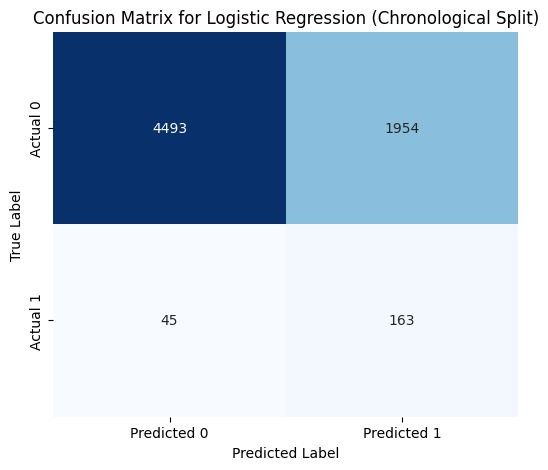

In [341]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm_lr_chrono = confusion_matrix(y_test_chrono, y_pred_lr_chrono)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr_chrono, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression (Chronological Split)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/Fig6.svg', format='svg', dpi=300)
files.download('/content/Fig6.svg')
plt.show()


In [342]:
from sklearn.ensemble import RandomForestClassifier
rf_chrono = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train the model on the chronologically split training data
rf_chrono.fit(X_train_chrono, y_train_chrono)

print("Random Forest model (chronological split) trained successfully.")

Random Forest model (chronological split) trained successfully.


In [343]:
from sklearn.metrics import classification_report

# Make predictions on the chronological test data using the Random Forest model
y_pred_rf_chrono = rf_chrono.predict(X_test_chrono)

# Evaluate the Random Forest model
print("Classification Report for Random Forest (Chronological Split):")
print(classification_report(y_test_chrono, y_pred_rf_chrono))

Classification Report for Random Forest (Chronological Split):
              precision    recall  f1-score   support

       False       0.99      1.00      0.99      6447
        True       0.93      0.55      0.69       208

    accuracy                           0.98      6655
   macro avg       0.96      0.77      0.84      6655
weighted avg       0.98      0.98      0.98      6655



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

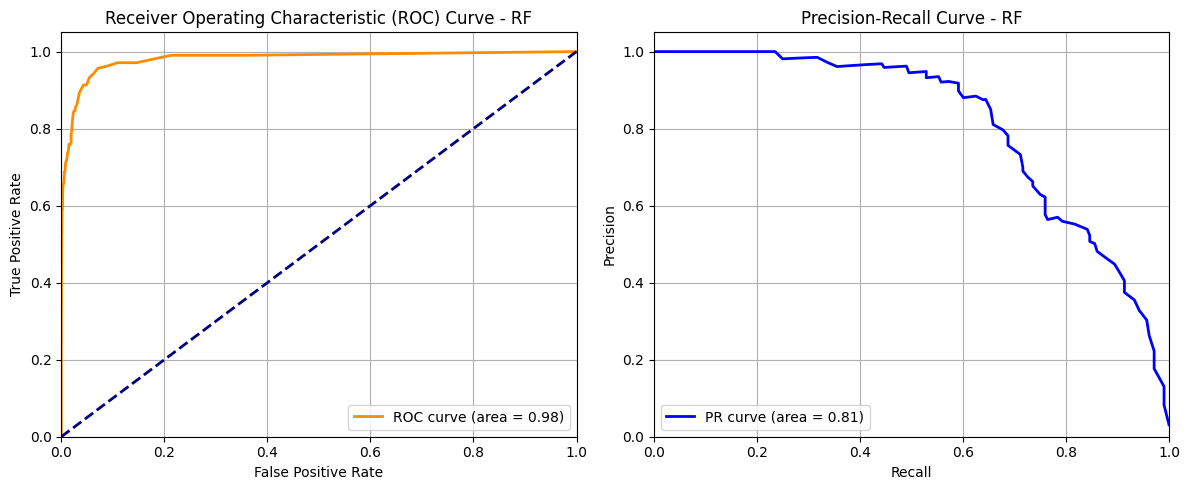

ROC-AUC Score for Random Forest (Chronological Split): 0.98
PR-AUC Score for Random Forest (Chronological Split): 0.81


In [344]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_prob_rf_chrono = rf_chrono.predict_proba(X_test_chrono)[:, 1]

# Calculate ROC curve and AUC
fpr_rf_chrono, tpr_rf_chrono, thresholds_roc_rf = roc_curve(y_test_chrono, y_prob_rf_chrono)
roc_auc_rf_chrono = auc(fpr_rf_chrono, tpr_rf_chrono)

# Calculate Precision-Recall curve and AUC
precision_rf_chrono, recall_rf_chrono, thresholds_pr_rf = precision_recall_curve(y_test_chrono, y_prob_rf_chrono)
pr_auc_rf_chrono = auc(recall_rf_chrono, precision_rf_chrono)

# Plot ROC Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_rf_chrono, tpr_rf_chrono, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf_chrono:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - RF')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_rf_chrono, precision_rf_chrono, color='blue', lw=2, label=f'PR curve (area = {pr_auc_rf_chrono:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - RF')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/Fig7.svg', format='svg', dpi=300)
files.download('/content/Fig7.svg')
plt.show()

print(f"ROC-AUC Score for Random Forest (Chronological Split): {roc_auc_rf_chrono:.2f}")
print(f"PR-AUC Score for Random Forest (Chronological Split): {pr_auc_rf_chrono:.2f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

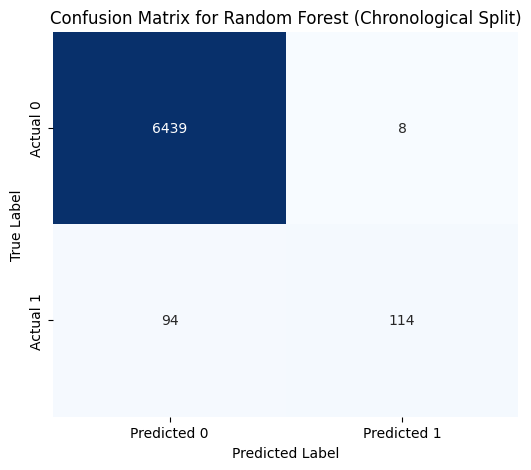

In [345]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm_rf_chrono = confusion_matrix(y_test_chrono, y_pred_rf_chrono)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_chrono, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest (Chronological Split)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/Fig8.svg', format='svg', dpi=300)
files.download('/content/Fig8.svg')
plt.show()


In [346]:
from sklearn.svm import SVC
svm_chrono = SVC(class_weight='balanced', random_state=42, probability=True)

# Train the model on the chronologically split training data
svm_chrono.fit(X_train_chrono, y_train_chrono)

print("Support Vector Machine (chronological split) trained successfully.")

Support Vector Machine (chronological split) trained successfully.


In [347]:
from sklearn.metrics import classification_report

# Make predictions on the chronological test data using the SVM model
y_pred_svm_chrono = svm_chrono.predict(X_test_chrono)

# Evaluate the SVM model
print("Classification Report for Support Vector Machine (Chronological Split):")
print(classification_report(y_test_chrono, y_pred_svm_chrono))

Classification Report for Support Vector Machine (Chronological Split):
              precision    recall  f1-score   support

       False       1.00      0.99      0.99      6447
        True       0.72      0.89      0.80       208

    accuracy                           0.99      6655
   macro avg       0.86      0.94      0.89      6655
weighted avg       0.99      0.99      0.99      6655



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

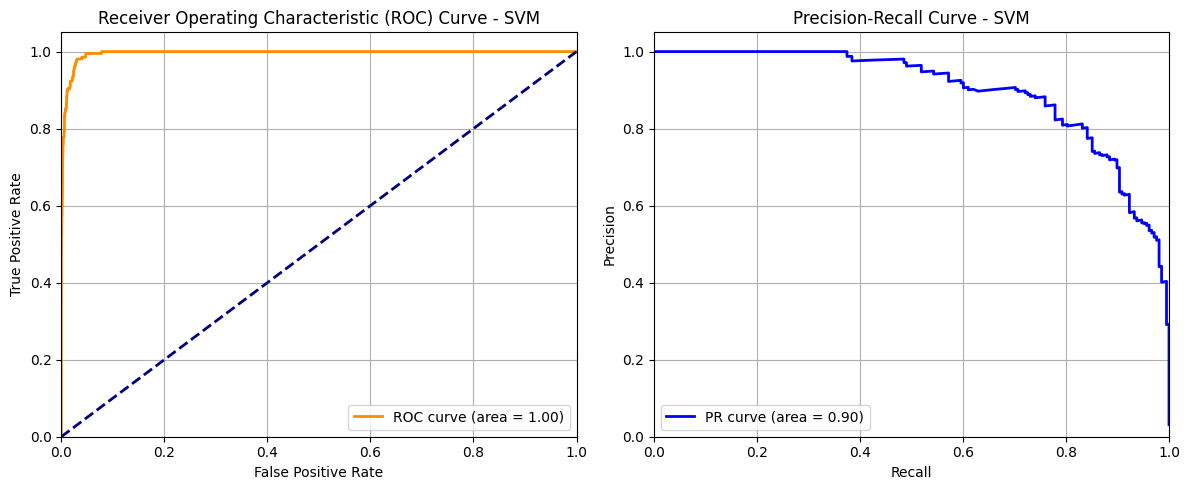

ROC-AUC Score for Support Vector Machine (Chronological Split): 1.00
PR-AUC Score for Support Vector Machine (Chronological Split): 0.90


In [348]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the SVM model
y_prob_svm_chrono = svm_chrono.predict_proba(X_test_chrono)[:, 1]

# Calculate ROC curve and AUC for SVM
fpr_svm_chrono, tpr_svm_chrono, thresholds_roc_svm = roc_curve(y_test_chrono, y_prob_svm_chrono)
roc_auc_svm_chrono = auc(fpr_svm_chrono, tpr_svm_chrono)

# Calculate Precision-Recall curve and AUC for SVM
precision_svm_chrono, recall_svm_chrono, thresholds_pr_svm = precision_recall_curve(y_test_chrono, y_prob_svm_chrono)
pr_auc_svm_chrono = auc(recall_svm_chrono, precision_svm_chrono)

# Plot ROC Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_svm_chrono, tpr_svm_chrono, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_svm_chrono:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - SVM')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_svm_chrono, precision_svm_chrono, color='blue', lw=2, label=f'PR curve (area = {pr_auc_svm_chrono:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SVM')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/Fig9.svg', format='svg', dpi=300)
files.download('/content/Fig9.svg')
plt.show()

print(f"ROC-AUC Score for Support Vector Machine (Chronological Split): {roc_auc_svm_chrono:.2f}")
print(f"PR-AUC Score for Support Vector Machine (Chronological Split): {pr_auc_svm_chrono:.2f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

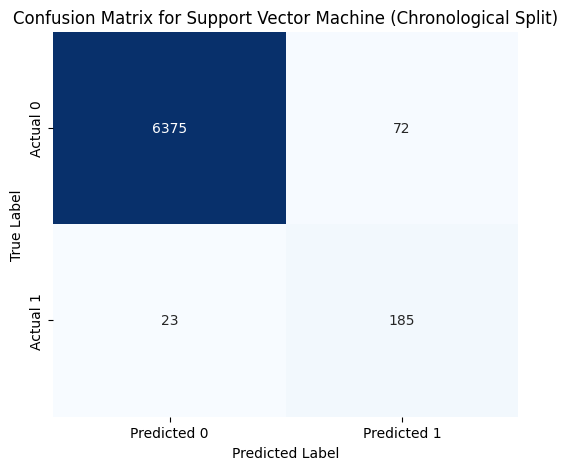

In [349]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for SVM
cm_svm_chrono = confusion_matrix(y_test_chrono, y_pred_svm_chrono)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm_chrono, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Support Vector Machine (Chronological Split)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/Fig10.svg', format='svg', dpi=300)
files.download('/content/Fig10.svg')
plt.show()

In [350]:
from xgboost import XGBClassifier
import numpy as np

# Calculate scale_pos_weight for handling potential imbalance in y_train_chrono
neg_count_chrono = (y_train_chrono == 0).sum()
pos_count_chrono = (y_train_chrono == 1).sum()
# Avoid division by zero if positive_class is absent
scale_pos_weight_chrono = neg_count_chrono / pos_count_chrono if pos_count_chrono > 0 else 1

xgb_chrono = XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                           scale_pos_weight=scale_pos_weight_chrono, random_state=42)

# Train the model on the chronologically split training data
xgb_chrono.fit(X_train_chrono, y_train_chrono)

print("XGBoost model (chronological split) trained successfully.")

XGBoost model (chronological split) trained successfully.


## SHAP Interpretability Analysis

In [351]:

# SHAP CELL  — Install SHAP and Build the Explainer

!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Convert test set to a named DataFrame
X_test_df = pd.DataFrame(X_test_chrono, columns=feature_cols)

# FIX: use shap.Explainer (the universal entry-point) instead of
#    TreeExplainer directly.  shap.Explainer auto-selects TreeExplainer
#    internally but handles the XGBoost ≥2.0 booster format correctly.
#    masker=X_train_df gives SHAP a background distribution to compute
#    E[f(X)] — use a 200-row sample for speed (full set also works).
X_train_df  = pd.DataFrame(X_train_chrono, columns=feature_cols)
background  = shap.sample(X_train_df, 200, random_state=42)   # background sample

explainer   = shap.Explainer(xgb_chrono, background)          # auto → TreeExplainer

# shap_values is an Explanation object; .values gives the numpy array
shap_obj    = explainer(X_test_df)
shap_values = shap_obj.values          # shape (n_test, n_features)
base_value  = shap_obj.base_values[0]  # scalar — average model output

# Pre-compute mean absolute SHAP (used in every subsequent cell)
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=feature_cols
).sort_values(ascending=False)

print("SHAP explainer ready.")
print(f"  Test set shape          : {X_test_df.shape}")
print(f"  SHAP values shape       : {shap_values.shape}")
print(f"  Base value (avg output) : {base_value:.4f}")
print(f"  Top feature by |SHAP|   : {mean_abs_shap.idxmax()}")
print(f"  Top |SHAP| value        : {mean_abs_shap.max():.5f}")

SHAP explainer ready.
  Test set shape          : (6655, 196)
  SHAP values shape       : (6655, 196)
  Base value (avg output) : 10.6148
  Top feature by |SHAP|   : ToolPosition_x_mean
  Top |SHAP| value        : 0.00000


In [352]:
from sklearn.metrics import classification_report

# Make predictions on the chronological test data using the XGBoost model
y_pred_xgb_chrono = xgb_chrono.predict(X_test_chrono)

# Evaluate the XGBoost model
print("Classification Report for XGBoost (Chronological Split):")
print(classification_report(y_test_chrono, y_pred_xgb_chrono))

Classification Report for XGBoost (Chronological Split):
              precision    recall  f1-score   support

       False       0.99      1.00      0.99      6447
        True       0.87      0.72      0.79       208

    accuracy                           0.99      6655
   macro avg       0.93      0.86      0.89      6655
weighted avg       0.99      0.99      0.99      6655



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

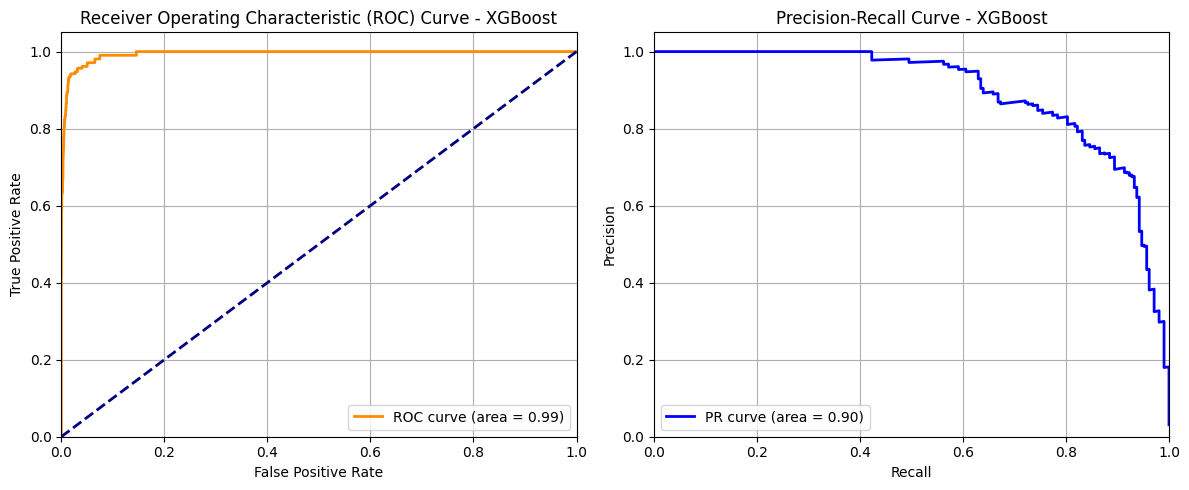

ROC-AUC Score for XGBoost (Chronological Split): 0.99
PR-AUC Score for XGBoost (Chronological Split): 0.90


In [353]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the XGBoost model
y_prob_xgb_chrono = xgb_chrono.predict_proba(X_test_chrono)[:, 1]

# Calculate ROC curve and AUC for XGBoost
fpr_xgb_chrono, tpr_xgb_chrono, thresholds_roc_xgb = roc_curve(y_test_chrono, y_prob_xgb_chrono)
roc_auc_xgb_chrono = auc(fpr_xgb_chrono, tpr_xgb_chrono)

# Calculate Precision-Recall curve and AUC for XGBoost
precision_xgb_chrono, recall_xgb_chrono, thresholds_pr_xgb = precision_recall_curve(y_test_chrono, y_prob_xgb_chrono)
pr_auc_xgb_chrono = auc(recall_xgb_chrono, precision_xgb_chrono)

# Plot ROC Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_xgb_chrono, tpr_xgb_chrono, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_xgb_chrono:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_xgb_chrono, precision_xgb_chrono, color='blue', lw=2, label=f'PR curve (area = {pr_auc_xgb_chrono:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/Fig11.svg', format='svg', dpi=300)
files.download('/content/Fig11.svg')
plt.show()

print(f"ROC-AUC Score for XGBoost (Chronological Split): {roc_auc_xgb_chrono:.2f}")
print(f"PR-AUC Score for XGBoost (Chronological Split): {pr_auc_xgb_chrono:.2f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

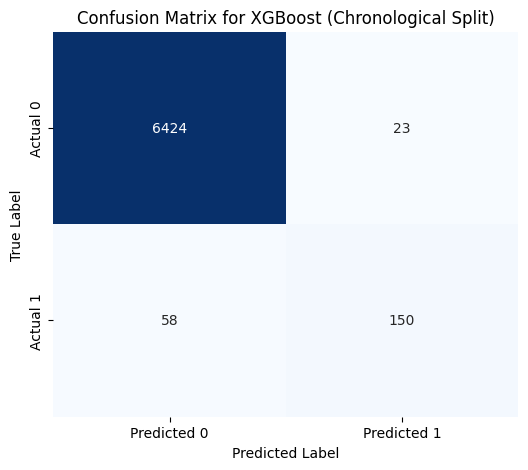

In [354]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for XGBoost
cm_xgb_chrono = confusion_matrix(y_test_chrono, y_pred_xgb_chrono)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_chrono, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for XGBoost (Chronological Split)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/Fig12.svg', format='svg', dpi=300)
files.download('/content/Fig12.svg')
plt.show()

In [355]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, auc, precision_recall_curve

# Collect Metrics for Logistic Regression
# Make sure y_pred_lr_chrono and y_prob_lr_chrono are available from previous execution
# If not, re-run the Logistic Regression evaluation cell

# Assuming y_pred_lr_chrono, y_prob_lr_chrono are from cell '646de2c7' and '2d5f8441'
# and y_test_chrono from data splitting

log_reg_metrics = {
    'Accuracy': accuracy_score(y_test_chrono, y_pred_lr_chrono),
    'Precision': precision_score(y_test_chrono, y_pred_lr_chrono, zero_division=0),
    'Recall': recall_score(y_test_chrono, y_pred_lr_chrono, zero_division=0),
    'F1-score': f1_score(y_test_chrono, y_pred_lr_chrono, zero_division=0),
    'ROC-AUC': roc_auc_lr_chrono, # from cell '2d5f8441'
    'PR-AUC': pr_auc_lr_chrono    # from cell '2d5f8441'
}

# Collect Metrics for Random Forest
# Assuming y_pred_rf_chrono, y_prob_rf_chrono are from cell 'zQwO0bVoixAQ' and '2RoRjN1JjH_u'

rf_metrics = {
    'Accuracy': accuracy_score(y_test_chrono, y_pred_rf_chrono),
    'Precision': precision_score(y_test_chrono, y_pred_rf_chrono, zero_division=0),
    'Recall': recall_score(y_test_chrono, y_pred_rf_chrono, zero_division=0),
    'F1-score': f1_score(y_test_chrono, y_pred_rf_chrono, zero_division=0),
    'ROC-AUC': roc_auc_rf_chrono, # from cell '2RoRjN1JjH_u'
    'PR-AUC': pr_auc_rf_chrono    # from cell '2RoRjN1JjH_u'
}

# Collect Metrics for SVM
# Assuming y_pred_svm_chrono, y_prob_svm_chrono are from cell 'DHwW3pCcswAl' and 'n97EQAU6tUqt'

svm_metrics = {
    'Accuracy': accuracy_score(y_test_chrono, y_pred_svm_chrono),
    'Precision': precision_score(y_test_chrono, y_pred_svm_chrono, zero_division=0),
    'Recall': recall_score(y_test_chrono, y_pred_svm_chrono, zero_division=0),
    'F1-score': f1_score(y_test_chrono, y_pred_svm_chrono, zero_division=0),
    'ROC-AUC': roc_auc_svm_chrono, # from cell 'n97EQAU6tUqt'
    'PR-AUC': pr_auc_svm_chrono    # from cell 'n97EQAU6tUqt'
}

# Collect Metrics for XGBoost
# Assuming y_pred_xgb_chrono, y_prob_xgb_chrono are from cell 'R4Ux42d9ujoY' and 'UoDzIlFuvBFk'

xgb_metrics = {
    'Accuracy': accuracy_score(y_test_chrono, y_pred_xgb_chrono),
    'Precision': precision_score(y_test_chrono, y_pred_xgb_chrono, zero_division=0),
    'Recall': recall_score(y_test_chrono, y_pred_xgb_chrono, zero_division=0),
    'F1-score': f1_score(y_test_chrono, y_pred_xgb_chrono, zero_division=0),
    'ROC-AUC': roc_auc_xgb_chrono, # from cell 'UoDzIlFuvBFk'
    'PR-AUC': pr_auc_xgb_chrono    # from cell 'UoDzIlFuvBFk'
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Logistic Regression': log_reg_metrics,
    'Random Forest': rf_metrics,
    'SVM': svm_metrics,
    'XGBoost': xgb_metrics
}).T # Transpose to have models as rows

# Format for better readability
comparison_df = comparison_df.round(4)

print("\n--- Model Performance Comparison (Chronological Test Split) ---")
display(comparison_df)


--- Model Performance Comparison (Chronological Test Split) ---


,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
Logistic Regression,0.6996,0.0770,0.7837,0.1402,0.7984,0.1826
Random Forest,0.9847,0.9344,0.5481,0.6909,0.9808,0.8102
SVM,0.9857,0.7198,0.8894,0.7957,0.9955,0.8992
XGBoost,0.9878,0.8671,0.7212,0.7874,0.9939,0.8963


In [356]:
# Code to automatically generate the styled LaTeX code for Table: cross_user
# Run this cell after creating comparison_df to print the ready-to-paste LaTeX code

def export_to_latex_table(df):
    columns_to_keep = ['Precision', 'Recall', 'F1-score', 'PR-AUC']
    df_filtered = df[[c for c in columns_to_keep if c in df.columns]].copy()

    # Optional: Filter specific models if needed
    # If you want to include Logistic Regression as well, just comment out the line below
    df_filtered = df_filtered.loc[df_filtered.index.isin(['Random Forest', 'SVM', 'XGBoost'])]

    latex_lines = []
    latex_lines.append(r"\begin{table}[htbp]")
    latex_lines.append(r"\caption{Cross-User Generalisation Performance Matrix}")
    latex_lines.append(r"\label{tab:cross_user}")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\begin{small}")
    latex_lines.append(r"\begin{tabular}{l" + "c" * len(df_filtered.columns) + "}")
    latex_lines.append(r"\hline")

    # Header formatting
    headers = [r"\textbf{Model}"] + [f"\\textbf{{{c.replace('F1-score', 'F1-Score')}}}" for c in df_filtered.columns]
    latex_lines.append(" & ".join(headers) + r" \\ \hline")

    # Automatically find maximum value per column to bold the best results
    max_vals = df_filtered.max()

    for model_name, row in df_filtered.iterrows():
        row_str = [f"{model_name}"]
        for col in df_filtered.columns:
            val = row[col]
            val_str = f"{val:.4f}"
            # Apply bold formatting to the highest score in each metric column
            if val == max_vals[col]:
                val_str = f"\\textbf{{{val_str}}}"
            row_str.append(val_str)
        latex_lines.append(" & ".join(row_str) + r"          \\")

    latex_lines.append(r"\hline")
    latex_lines.append(r"\end{tabular}")
    latex_lines.append(r"\end{small}")
    latex_lines.append(r"\end{table}")

    return "\n".join(latex_lines)

# Generate and print the LaTeX code
latex_table_code = export_to_latex_table(comparison_df)
print(latex_table_code)

\begin{table}[htbp]
\caption{Cross-User Generalisation Performance Matrix}
\label{tab:cross_user}
\centering
\begin{small}
\begin{tabular}{lcccc}
\hline
\textbf{Model} & \textbf{Precision} & \textbf{Recall} & \textbf{F1-Score} & \textbf{PR-AUC} \\ \hline
Random Forest & \textbf{0.9344} & 0.5481 & 0.6909 & 0.8102          \\
SVM & 0.7198 & \textbf{0.8894} & \textbf{0.7957} & \textbf{0.8992}          \\
XGBoost & 0.8671 & 0.7212 & 0.7874 & 0.8963          \\
\hline
\end{tabular}
\end{small}
\end{table}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

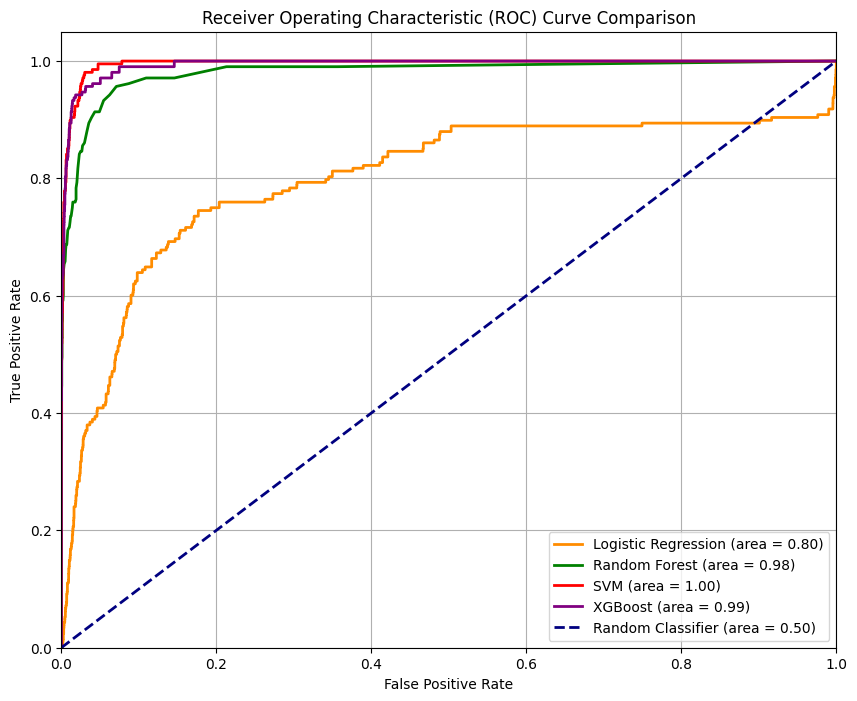

In [357]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot ROC for Logistic Regression
plt.plot(fpr_lr_chrono, tpr_lr_chrono, color='darkorange', lw=2, label=f'Logistic Regression (area = {roc_auc_lr_chrono:.2f})')

# Plot ROC for Random Forest
plt.plot(fpr_rf_chrono, tpr_rf_chrono, color='green', lw=2, label=f'Random Forest (area = {roc_auc_rf_chrono:.2f})')

# Plot ROC for SVM
plt.plot(fpr_svm_chrono, tpr_svm_chrono, color='red', lw=2, label=f'SVM (area = {roc_auc_svm_chrono:.2f})')

# Plot ROC for XGBoost
plt.plot(fpr_xgb_chrono, tpr_xgb_chrono, color='purple', lw=2, label=f'XGBoost (area = {roc_auc_xgb_chrono:.2f})')

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (area = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('/content/Fig13.svg', format='svg', dpi=300)
files.download('/content/Fig13.svg')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

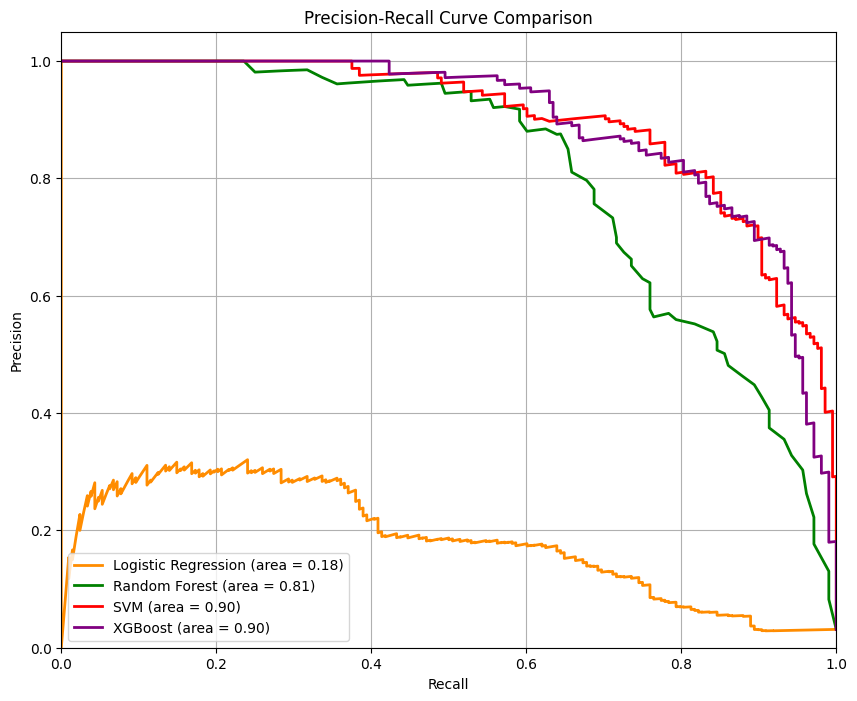

In [358]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot PR for Logistic Regression
plt.plot(recall_lr_chrono, precision_lr_chrono, color='darkorange', lw=2, label=f'Logistic Regression (area = {pr_auc_lr_chrono:.2f})')

# Plot PR for Random Forest
plt.plot(recall_rf_chrono, precision_rf_chrono, color='green', lw=2, label=f'Random Forest (area = {pr_auc_rf_chrono:.2f})')

# Plot PR for SVM
plt.plot(recall_svm_chrono, precision_svm_chrono, color='red', lw=2, label=f'SVM (area = {pr_auc_svm_chrono:.2f})')

# Plot PR for XGBoost
plt.plot(recall_xgb_chrono, precision_xgb_chrono, color='purple', lw=2, label=f'XGBoost (area = {pr_auc_xgb_chrono:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig('/content/Fig14.svg', format='svg', dpi=300)
files.download('/content/Fig14.svg')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

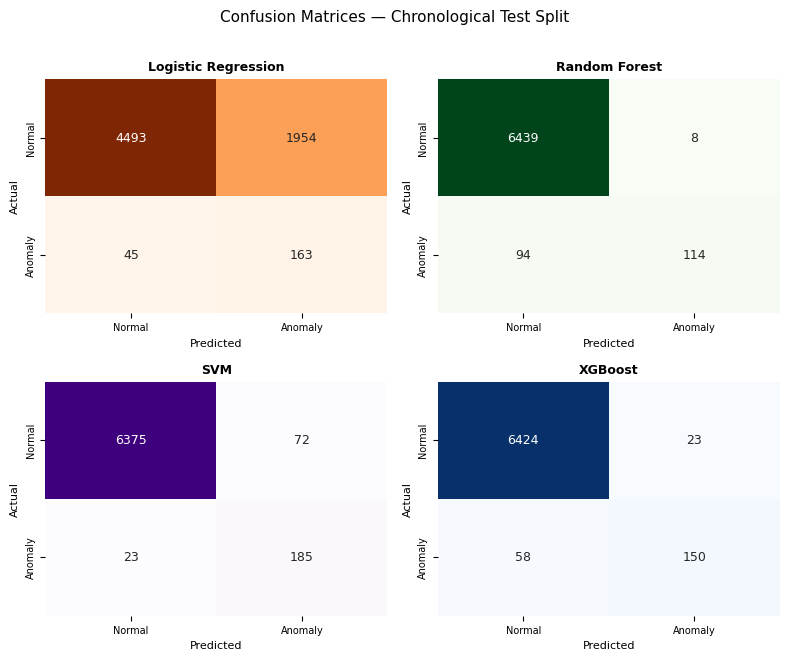

In [359]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(8, 6.5))
fig.suptitle('Confusion Matrices — Chronological Test Split',
             fontsize=11, fontweight='normal', y=1.01)

models = [
    ('Logistic Regression', y_test_chrono, y_pred_lr_chrono),
    ('Random Forest',       y_test_chrono, y_pred_rf_chrono),
    ('SVM',                 y_test_chrono, y_pred_svm_chrono),
    ('XGBoost',             y_test_chrono, y_pred_xgb_chrono),
]
cmaps = ['Oranges', 'Greens', 'Purples', 'Blues']

for ax, (name, y_true, y_pred), cmap in zip(axes.flat, models, cmaps):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=ax,
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'],
                annot_kws={'size': 9})
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('/content/Fig_CM_panel.pdf', format='pdf', dpi=300, bbox_inches='tight')
files.download('/content/Fig_CM_panel.pdf')
plt.show()

---
## LSTM Deep Learning — Comparison with XGBoost

In [360]:
# LSTM CELL  — Sequence Data Preparation
# LSTM operates on raw sensor windows (shape: samples × timesteps × features)
# NOT on engineered features — this is by design: LSTM learns its own features.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

WINDOW       = 10          # same window size as XGBoost pipeline
RANDOM_STATE = 42

#  Build raw sequence arrays from df (the preprocessed row-level DataFrame)
# Each window = WINDOW consecutive timesteps × n_sensor_channels
groups  = df.groupby("User_ID") if "User_ID" in df.columns else [("all", df)]
seq_X, seq_y = [], []

for uid, udf in groups:
    udf = udf.reset_index(drop=True)
    sensor_data = udf[available_sensors].values.astype(float)
    labels      = udf[TARGET_COL].values

    for i in range(0, len(udf) - WINDOW + 1, WINDOW):
        seq_X.append(sensor_data[i : i + WINDOW])   # shape (WINDOW, n_sensors)
        seq_y.append(int(labels[i : i + WINDOW].max()))

seq_X = np.array(seq_X)   # (n_windows, WINDOW, n_sensors)
seq_y = np.array(seq_y)   # (n_windows,)

# Invert label if needed (same guard as XGBoost pipeline)
if seq_y.mean() > 0.95:
    seq_y = 1 - seq_y

n_timesteps = seq_X.shape[1]
n_features  = seq_X.shape[2]
print(f"Sequence array  : {seq_X.shape}  (windows × timesteps × sensors)")
print(f"Anomaly rate    : {seq_y.mean()*100:.2f}%")

# Stratified 70/15/15 split
Xtv, X_test_lstm, ytv, y_test_lstm = train_test_split(
    seq_X, seq_y, test_size=0.15, stratify=seq_y, random_state=RANDOM_STATE)
X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    Xtv, ytv, test_size=0.15/0.85, stratify=ytv, random_state=RANDOM_STATE)

# Per-feature z-score normalisation (fit on train only, no leakage)
# Reshape to 2D for StandardScaler, then back to 3D
n_tr, n_t, n_f = X_train_lstm.shape
sc_lstm = StandardScaler()
X_train_lstm = sc_lstm.fit_transform(X_train_lstm.reshape(-1, n_f)).reshape(-1, n_t, n_f)
X_val_lstm   = sc_lstm.transform(X_val_lstm.reshape(-1, n_f)).reshape(-1, n_t, n_f)
X_test_lstm  = sc_lstm.transform(X_test_lstm.reshape(-1, n_f)).reshape(-1, n_t, n_f)

print(f"Train {X_train_lstm.shape} | Val {X_val_lstm.shape} | Test {X_test_lstm.shape}")
print(f"Train anomalies : {y_train_lstm.sum()} ({y_train_lstm.mean()*100:.1f}%)")

Sequence array  : (3314, 10, 21)  (windows × timesteps × sensors)
Anomaly rate    : 11.98%
Train (2319, 10, 21) | Val (497, 10, 21) | Test (498, 10, 21)
Train anomalies : 278 (12.0%)


In [361]:
# LSTM CELL — Build and Train LSTM
# Architecture: Stacked LSTM (64→32) + Dropout(0.3) + Dense(1, sigmoid)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

tf.random.set_seed(RANDOM_STATE)

# Class weight to handle ~12% anomaly rate
pos_lstm = y_train_lstm.sum()
neg_lstm = (y_train_lstm == 0).sum()
class_weight_lstm = {0: 1.0, 1: round(neg_lstm / max(pos_lstm, 1), 2)}
print(f"Class weights: {class_weight_lstm}")

# Model architecture
model_lstm = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(n_timesteps, n_features)),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    BatchNormalization(),
    Dense(16, activation="relu"),
    Dense(1,  activation="sigmoid"),
], name="Stacked_LSTM")

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
)
model_lstm.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor="val_pr_auc", patience=10,
                  restore_best_weights=True, mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                     patience=5, min_lr=1e-6, verbose=1),
]

#  Train
t0 = time.time()
history_lstm = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=60,
    batch_size=64,
    class_weight=class_weight_lstm,
    callbacks=callbacks,
    verbose=1,
)
lstm_train_time = time.time() - t0
print(f"\nLSTM training time : {lstm_train_time:.1f} s")
print(f"Epochs run         : {len(history_lstm.history['loss'])} "
      f"(early stopping patience=10)")

Class weights: {0: 1.0, 1: np.float64(7.34)}


Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 10, 64)         │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,105 (137.13 KB)

 Trainable params: 35,041 (136.88 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.7305 - loss: 0.6748 - pr_auc: 0.7542 - precision: 0.3026 - recall: 0.9568 - val_accuracy: 0.9557 - val_loss: 0.4921 - val_pr_auc: 0.9261 - val_precision: 0.7342 - val_recall: 0.9831 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9370 - loss: 0.3158 - pr_auc: 0.9351 - precision: 0.6610 - recall: 0.9748 - val_accuracy: 0.9879 - val_loss: 0.3362 - val_pr_auc: 0.9839 - val_precision: 0.9206 - val_recall: 0.9831 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9810 - loss: 0.1582 - pr_auc: 0.9902 - precision: 0.8703 - recall: 0.9892 - val_accuracy: 0.9940 - val_loss: 0.2196 - val_pr_auc: 0.9956 - val_precision: 0.9828 - val_recall: 0.9661 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.9879 - loss: 0.1038 - pr_auc: 0.9942 - precision: 0.9139 - recall: 0.9928 - val_accuracy: 0.9940 - val_loss: 0.1429 - va

Optimal threshold (Youden-J on val): 0.227

Classification Report — LSTM (Test Set):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       438
           1       0.88      1.00      0.94        60

    accuracy                           0.98       498
   macro avg       0.94      0.99      0.96       498
weighted avg       0.99      0.98      0.98       498

ROC-AUC : 0.9993
PR-AUC  : 0.9943
F1      : 0.9375
Accuracy: 0.9839


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

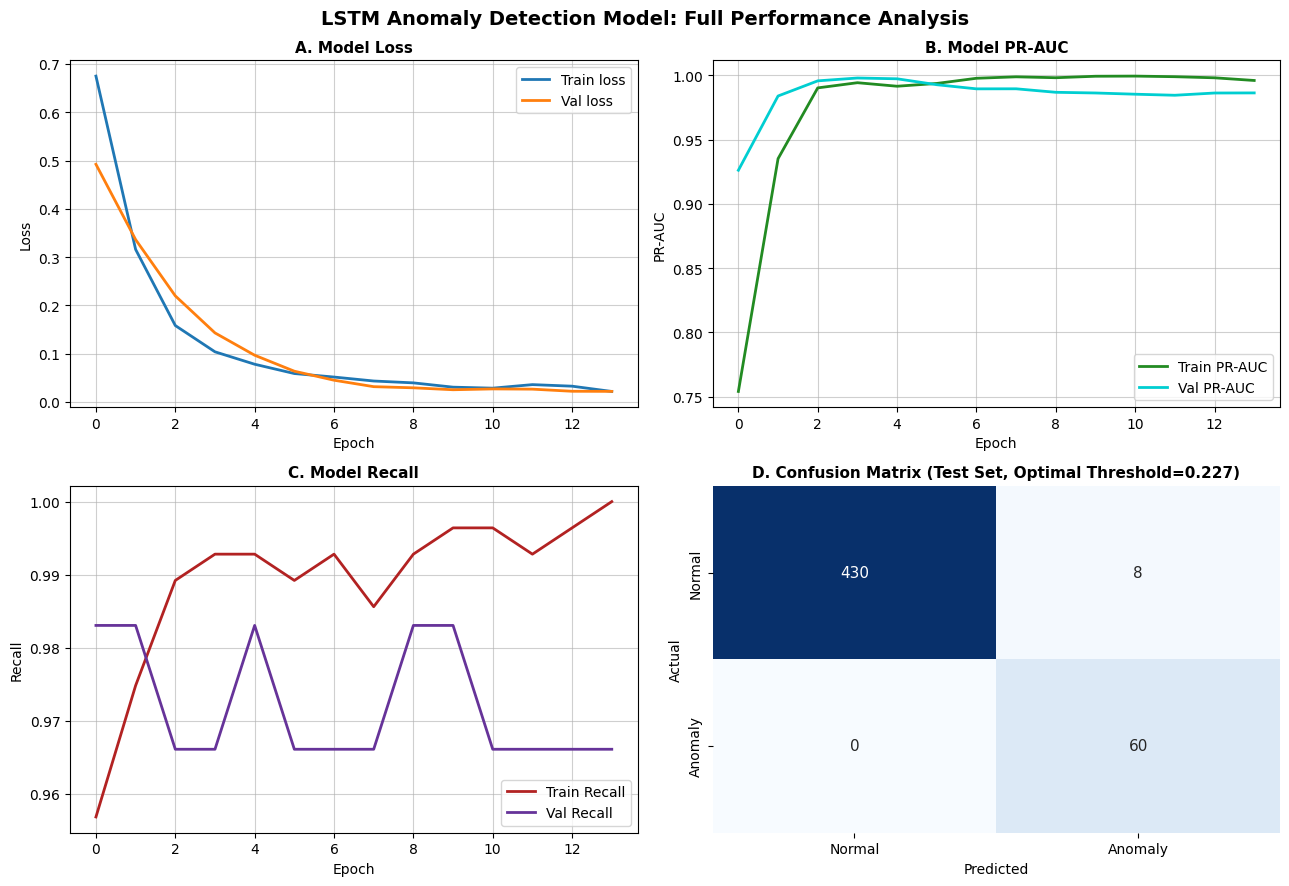

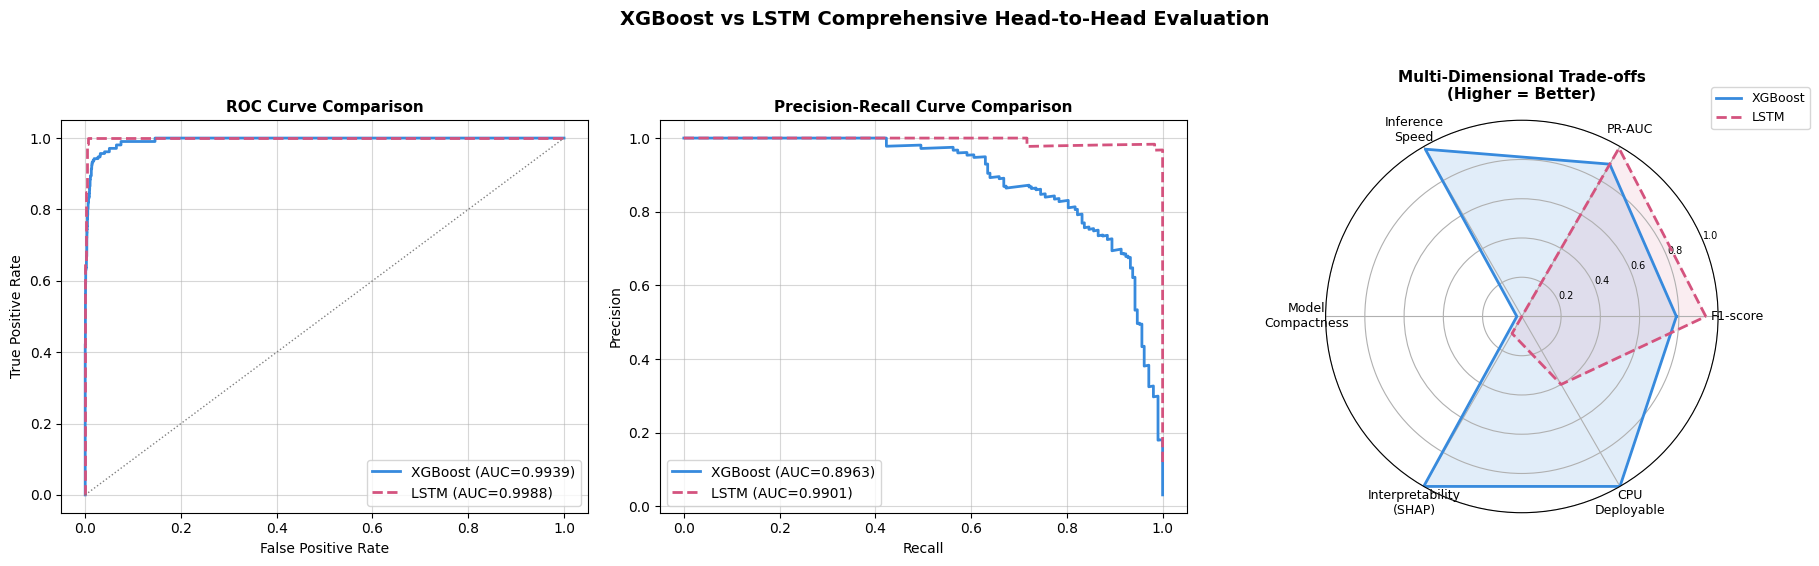

In [365]:
# LSTM CELL — Evaluate LSTM and Plot Training Curves
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve,
                              f1_score, accuracy_score,
                              precision_score, recall_score)

# Predictions
y_prob_lstm = model_lstm.predict(X_test_lstm, verbose=0).ravel()

# Optimise threshold on validation set using Youden-J (maximises sensitivity+specificity)
y_prob_val_lstm = model_lstm.predict(X_val_lstm, verbose=0).ravel()
thresholds_val  = np.linspace(0.01, 0.99, 200)
j_scores = []
for t in thresholds_val:
    pred_t = (y_prob_val_lstm >= t).astype(int)
    tp = ((pred_t == 1) & (y_val_lstm == 1)).sum()
    tn = ((pred_t == 0) & (y_val_lstm == 0)).sum()
    fp = ((pred_t == 1) & (y_val_lstm == 0)).sum()
    fn = ((pred_t == 0) & (y_val_lstm == 1)).sum()
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    j_scores.append(sens + spec - 1)
best_thresh_lstm = thresholds_val[np.argmax(j_scores)]
print(f"Optimal threshold (Youden-J on val): {best_thresh_lstm:.3f}")

y_pred_lstm = (y_prob_lstm >= best_thresh_lstm).astype(int)

# Classification report
print("\nClassification Report — LSTM (Test Set):")
print(classification_report(y_test_lstm, y_pred_lstm))

# ROC and PR curves
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_lstm, y_prob_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
prec_lstm, rec_lstm, _ = precision_recall_curve(y_test_lstm, y_prob_lstm)
pr_auc_lstm = auc(rec_lstm, prec_lstm)

print(f"ROC-AUC : {roc_auc_lstm:.4f}")
print(f"PR-AUC  : {pr_auc_lstm:.4f}")
print(f"F1      : {f1_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"Accuracy: {accuracy_score(y_test_lstm, y_pred_lstm):.4f}")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a 2x2 grid for the full performance dashboard
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('LSTM Anomaly Detection Model: Full Performance Analysis',
             fontsize=14, fontweight='bold', y=0.98)

# Subplot A: Model Loss (Top Left)
axes[0, 0].plot(history_lstm.history["loss"], label="Train loss", linewidth=2)
axes[0, 0].plot(history_lstm.history["val_loss"], label="Val loss", linewidth=2)
axes[0, 0].set_title("A. Model Loss", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Epoch", fontsize=10)
axes[0, 0].set_ylabel("Loss", fontsize=10)
axes[0, 0].legend(loc="upper right")
axes[0, 0].grid(True, linestyle='-', alpha=0.6)

# Subplot B: Model PR-AUC (Top Right)
axes[0, 1].plot(history_lstm.history["pr_auc"], label="Train PR-AUC", linewidth=2, color='forestgreen')
axes[0, 1].plot(history_lstm.history["val_pr_auc"], label="Val PR-AUC", linewidth=2, color='darkturquoise')
axes[0, 1].set_title("B. Model PR-AUC", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Epoch", fontsize=10)
axes[0, 1].set_ylabel("PR-AUC", fontsize=10)
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, linestyle='-', alpha=0.6)

# Subplot C: Model Recall (Bottom Left)
axes[1, 0].plot(history_lstm.history["recall"], label="Train Recall", linewidth=2, color='firebrick')
axes[1, 0].plot(history_lstm.history["val_recall"], label="Val Recall", linewidth=2, color='rebeccapurple')
axes[1, 0].set_title("C. Model Recall", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Epoch", fontsize=10)
axes[1, 0].set_ylabel("Recall", fontsize=10)
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True, linestyle='-', alpha=0.6)

# Subplot D: Confusion Matrix (Bottom Right)
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1, 1],
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"],
            annot_kws={'size': 11})
axes[1, 1].set_title(f"D. Confusion Matrix (Test Set, Optimal Threshold={best_thresh_lstm:.3f})",
                     fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Predicted", fontsize=10)
axes[1, 1].set_ylabel("Actual", fontsize=10)

# Layout Adjustments & Export
plt.tight_layout()

# Save the unified figure
output_path = "/content/Fig_LSTM_Full_Analysis.pdf"
plt.savefig(output_path, format="pdf", dpi=300, bbox_inches='tight')

try:
    from google.colab import files
    files.download(output_path)
except ImportError:
    pass


#  Setup Unified 3-Panel Visual Figure
fig = plt.figure(figsize=(19, 5.5))
fig.suptitle("XGBoost vs LSTM Comprehensive Head-to-Head Evaluation", fontsize=14, fontweight='bold', y=1.02)

# Subplot 1: ROC Curve (Linear Axis)
ax_roc = fig.add_subplot(1, 3, 1)
ax_roc.plot(fpr_xgb_c, tpr_xgb_c, color="#378ADD", lw=2, label=f"XGBoost (AUC={roc_xgb_c:.4f})")
ax_roc.plot(fpr_l, tpr_l, color="#D4537E", lw=2, linestyle="--", label=f"LSTM (AUC={roc_l:.4f})")
ax_roc.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
ax_roc.set_xlabel("False Positive Rate", fontsize=10)
ax_roc.set_ylabel("True Positive Rate", fontsize=10)
ax_roc.set_title("ROC Curve Comparison", fontsize=11, fontweight='bold')
ax_roc.legend(loc="lower right")
ax_roc.grid(True, alpha=0.5)

# Subplot 2: PR Curve (Linear Axis)
ax_pr = fig.add_subplot(1, 3, 2)
ax_pr.plot(rec_xgb_c, prec_xgb_c, color="#378ADD", lw=2, label=f"XGBoost (AUC={pr_xgb_c:.4f})")
ax_pr.plot(rec_lstm, prec_lstm, color="#D4537E", lw=2, linestyle="--", label=f"LSTM (AUC={pr_l:.4f})")
ax_pr.set_xlabel("Recall", fontsize=10)
ax_pr.set_ylabel("Precision", fontsize=10)
ax_pr.set_title("Precision-Recall Curve Comparison", fontsize=11, fontweight='bold')
ax_pr.legend(loc="lower left")
ax_pr.grid(True, alpha=0.5)

# Subplot 3: Radar Chart (Polar Axis)
ax_radar = fig.add_subplot(1, 3, 3, polar=True)

f1_xgb = f1_score(y_test_chrono, y_pred_xgb_)
f1_lstm = f1_score(y_test_lstm, y_pred_lstm)

# Normalise metrics to [0,1] for Radar scaling
speed_xgb  = 1.0 - (xgb_lat_ms  / max(xgb_lat_ms, lstm_lat_ms))
speed_lstm = 1.0 - (lstm_lat_ms / max(xgb_lat_ms, lstm_lat_ms))
size_xgb   = 1.0 - (xgb_size_kb  / max(xgb_size_kb, lstm_size_kb))
size_lstm  = 1.0 - (lstm_size_kb / max(xgb_size_kb, lstm_size_kb))

radar_labels  = ["F1-score", "PR-AUC", "Inference\nSpeed", "Model\nCompactness",
                 "Interpretability\n(SHAP)", "CPU\nDeployable"]
xgb_scores    = [f1_xgb,  pr_xgb_c, speed_xgb,  size_xgb,  1.0, 1.0]
lstm_scores   = [f1_lstm, pr_l,      speed_lstm, size_lstm, 0.1, 0.4]

angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]
xgb_scores  += xgb_scores[:1]
lstm_scores += lstm_scores[:1]

ax_radar.plot(angles, xgb_scores, color="#378ADD", lw=2, label="XGBoost")
ax_radar.fill(angles, xgb_scores, color="#378ADD", alpha=0.15)
ax_radar.plot(angles, lstm_scores, color="#D4537E", lw=2, linestyle="--", label="LSTM")
ax_radar.fill(angles, lstm_scores, color="#D4537E", alpha=0.10)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)
ax_radar.set_title("Multi-Dimensional Trade-offs\n(Higher = Better)", fontsize=11, fontweight='bold', pad=15)
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), fontsize=9)

# Layout Adjustments & Export
plt.tight_layout()
output_filename = "/content/Fig_XGB_vs_LSTM_Full_Panel.pdf"
plt.savefig(output_filename, format="pdf", dpi=300, bbox_inches="tight")

# Colab download wrapper
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
    pass

plt.show()